# Simple trafficability model

**Data:**
1. NISAR level 3 Soil moisture pruduct (uncalibrated)
2. International Soil Moisture Network (precipitation)
3. Corine landcover raster 2018
4. Saturated water content 15cm and 30cm (THS) - EU-SoilHydroGrids ver1.0 
5. Clay content (g/kg) - SoilGrids
6. sand content (g/kg) - SoilGrids
7. DEM - EU-DEM

NISAR raster is originally around 200m resolution. CRS for project is set to 4326. Rest of the rasters are reprojected to 4326 and then aligned and resampled to match NISAR raster as much as possible

Chosen AOI is around Andorra, southern France and northern Hispain. This is so because the uncalibrated data is available for winter months. Therefore area with no snow cover had to be chosen.

In [1]:
import nisarConvert as NC
import os
import numpy as np
import folium
from PIL import Image
import rasterio
import matplotlib.pyplot as plt
import contextily
import pandas as pd
from pathlib import Path
import datetime
import geopandas as gpd
from rasterstats import point_query
from rasterio.transform import xy
from rasterio.warp import reproject, Resampling
from rasterio.merge import merge
from scipy.ndimage import uniform_filter
from rasterio.windows import from_bounds
import rioxarray as rxr
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch


# Converting NISAR data

NISAR data comes in h5 format which is basically a datacube. This means it contains multiple layers of data.

To get the right layers i created a script that is imported here as NC. This is so i could use thi later as well for my thesis.

In [34]:
input_fol = 'data'
output_fol = 'data/gtiff_data'
os.makedirs(output_fol, exist_ok=True)
NC.convert_folder(input_fol, output_fol)


=== Processing NISAR_L3_PR_SME2_010_066_D_067_2005_DHDH_A_20260113T185214_20260113T185249_X05010_N_F_J_001.h5 ===
Wrote data/gtiff_data/soilMoisture.tif
Wrote data/gtiff_data/soilMoistureUncertainty.tif
[WARN] Missing layer qualityFlag, skipping
[WARN] Missing layer waterBodyFraction, skipping
[WARN] Missing layer vegetationWaterContent, skipping
Reprojected data/gtiff_data/reproj/corine_clip_4326.tif
Reprojected data/gtiff_data/reproj/clay_05-15_4326.tif
Reprojected data/gtiff_data/reproj/ths_30_4326.tif
Reprojected data/gtiff_data/reproj/soilMoistureUncertainty_4326.tif
Reprojected data/gtiff_data/reproj/sand_05-15_4326.tif
Reprojected data/gtiff_data/reproj/soilMoisture_4326.tif
Reprojected data/gtiff_data/reproj/corine_4326.tif
Reprojected data/gtiff_data/reproj/ths_15_4326.tif


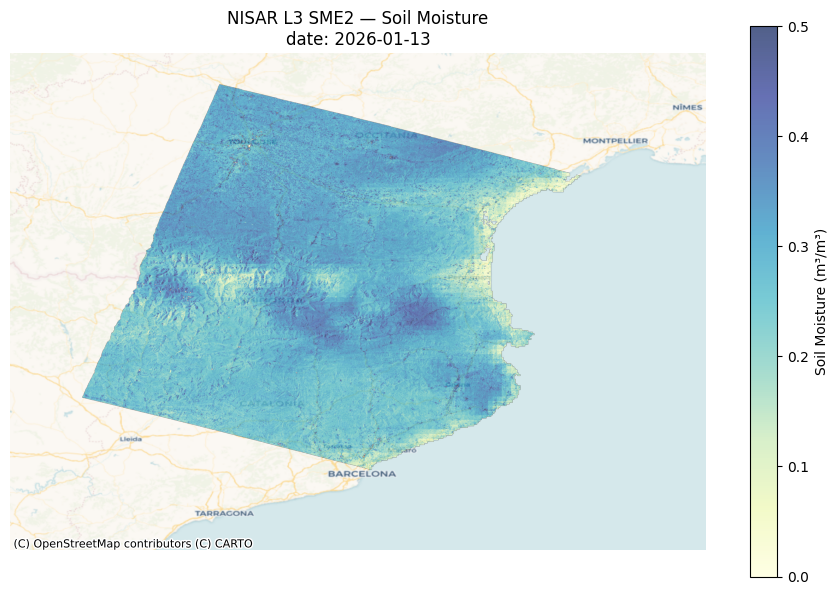

In [3]:
#ploting the data

sm_fp = "data/gtiff_data/reproj/soilMoisture_4326.tif"
with rasterio.open(sm_fp) as src:
    data = src.read(1, masked=True)
    bounds = src.bounds  # left, bottom, right, top

fig, ax = plt.subplots(figsize=(9, 6))

# Draw raster first
img = ax.imshow(
    data,
    cmap="YlGnBu",
    vmin=0, vmax=0.5,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
    origin='upper',
    zorder=2,
    alpha=0.7
)

# Lock axes limits to raster extent BEFORE adding basemap
ax.set_xlim(bounds.left, bounds.right)
ax.set_ylim(bounds.bottom, bounds.top)

# Now add basemap — it will tile to the already-locked extent
contextily.add_basemap(
    ax,
    source=contextily.providers.CartoDB.Voyager,
    crs="EPSG:4326",
    zorder=1
)

plt.colorbar(img, ax=ax, label="Soil Moisture (m³/m³)")
ax.set_title("NISAR L3 SME2 — Soil Moisture\ndate: 2026-01-13")
ax.axis("off")
plt.tight_layout()
plt.show()



# International Soil Moisture Network (ISMN) data

The availability of precipitation data played a crucial role also when choosing AOI. Although ISMN main purpose is to make soil moisture data accessible, there are other weather parameters also. 

Precipitation data for 2026-01-13 was available.

Data can be downloaded from ISMN site https://ismn.earth/en/data/ 

Data is provided originalli in .stm format which need converting to use as a dataframe in python


In [4]:
### extracting precipitation data from ISMN data


def read_stm_file(path):
    with open(path, "r") as f:
        lines = f.readlines()

    # Parse metadata line 
    meta = lines[0].split()
    network = meta[0]
    station = meta[2]
    lat = float(meta[3])
    lon = float(meta[4])
    elevation = float(meta[5])
    depth1 = float(meta[6])
    depth2 = float(meta[7])
    sensor = meta[8]

    # Parse data lines
    data_rows = []
    for line in lines[1:]:
        parts = line.split()
        date = parts[0]
        time = parts[1]
        value = float(parts[2])  # precipitation
        label1 = parts[3]
        label2 = parts[4]

        data_rows.append({
            "datetime": pd.to_datetime(f"{date} {time}"),
            "precip_mm": value,
            "label1": label1,
            "label2": label2,
            "network": network,
            "station": station,
            "lat": lat,
            "lon": lon,
            "elevation": elevation,
            "depth1": depth1,
            "depth2": depth2,
            "sensor": sensor
        })
    df = pd.DataFrame(data_rows)
    df["date"] = df["datetime"].dt.date

    daily = (
    df.groupby("date")
      .agg({
          "precip_mm": "sum",
          "network": "first",
          "station": "first",
          "lat": "first",
          "lon": "first",
          "elevation": "first",
          "depth1": "first",
          "depth2": "first",
          "sensor": "first"
      })
      .reset_index()
    )

    
    return daily

def convert_stm_files(root_path, variable):
    root = Path(root_path)
    all_daily = []   # list to collect daily DataFrames

    for file in root.rglob(f"*_{variable}_*.stm"):
        daily_df = read_stm_file(file)
        all_daily.append(daily_df)

    # merging all stations into one big DataFrame
    if all_daily:
        return pd.concat(all_daily, ignore_index=True)
    else:
        return pd.DataFrame() 


In [5]:
#extracting only precipitation
ismn = convert_stm_files("data/ismn_data", 'p') # p stands for precipitation
display(ismn.head(20))


,date,precip_mm,network,station,lat,lon,elevation,depth1,depth2,sensor
0,2026-01-01,0.0,XMS-CAT,El_Boixer,42.39871,0.95839,1217.0,-2.0,-2.5,Lambrecht_15189
1,2026-01-02,0.0,XMS-CAT,El_Boixer,42.39871,0.95839,1217.0,-2.0,-2.5,Lambrecht_15189
2,2026-01-03,2.0,XMS-CAT,El_Boixer,42.39871,0.95839,1217.0,-2.0,-2.5,Lambrecht_15189
3,2026-01-04,4.6,XMS-CAT,El_Boixer,42.39871,0.95839,1217.0,-2.0,-2.5,Lambrecht_15189
4,2026-01-05,0.9,XMS-CAT,El_Boixer,42.39871,0.95839,1217.0,-2.0,-2.5,Lambrecht_15189
5,2026-01-06,0.0,XMS-CAT,El_Boixer,42.39871,0.95839,1217.0,-2.0,-2.5,Lambrecht_15189
6,2026-01-07,0.0,XMS-CAT,El_Boixer,42.39871,0.95839,1217.0,-2.0,-2.5,Lambrecht_15189
7,2026-01-08,0.0,XMS-CAT,El_Boixer,42.39871,0.95839,1217.0,-2.0,-2.5,Lambrecht_15189
8,2026-01-09,1.2,XMS-CAT,El_Boixer,42.39871,0.95839,1217.0,-2.0,-2.5,Lambrecht_15189
9,2026-01-10,1.1,XMS-CAT,El_Boixer,42.39871,0.95839,1217.0,-2.0,-2.5,Lambrecht_15189


In [6]:
# Selecting only the target date
target_date = datetime.date(2026, 1, 13)
precip = ismn[ismn['date'] == target_date]
display(precip.head(20))
print(len(precip))
print('Sum of precipitation:', sum(precip['precip_mm']), 'mm')

,date,precip_mm,network,station,lat,lon,elevation,depth1,depth2,sensor
12,2026-01-13,0.0,XMS-CAT,El_Boixer,42.39871,0.95839,1217.0,-2.0,-2.5,Lambrecht_15189
43,2026-01-13,0.0,XMS-CAT,Serra_de_Costa_Ampla,42.21120,0.89390,922.0,-2.0,-2.5,Young_52203
74,2026-01-13,0.0,XMS-CAT,Clot_de_les_Peres_II,42.15623,0.83767,602.0,-2.0,-2.5,Young_52203
105,2026-01-13,0.0,XMS-CAT,Batlliu_de_Sort,42.42841,1.12440,890.0,-2.0,-2.5,Lambrecht_15189
136,2026-01-13,0.0,XMS-CAT,Torre_del_Lluvia,41.72531,1.79065,258.0,-2.0,-2.5,Lambrecht_15189
167,2026-01-13,0.0,XMS-CAT,Clarella,42.11946,2.28235,922.0,-2.0,-2.5,Lambrecht_15189
198,2026-01-13,0.0,XMS-CAT,Aguilar_de_Segarra,41.75145,1.62303,527.0,-2.0,-2.5,Lambrecht_15189
229,2026-01-13,0.0,XMS-CAT,Cami_dels_Nerets,42.15540,0.92550,487.0,-2.0,-2.5,Young_52203
260,2026-01-13,0.0,XMS-CAT,Ribera_de_Sio,41.80319,0.90969,283.0,-2.0,-2.5,Lambrecht_15189
291,2026-01-13,0.0,XMS-CAT,Los_Coscolls,42.14571,0.98318,560.0,-2.0,-2.5,Young_52203


21
Sum of precipitation: 0.1 mm


In [7]:
#creating geodataframe of points
precip_gdf = gpd.GeoDataFrame(precip, geometry=gpd.points_from_xy(precip['lon'], precip['lat']), crs="EPSG:4326")
precip_gdf.drop(['lat', 'lon'], axis=1, inplace=True) #not needing lat and lon column anymore
display(precip_gdf)


,date,precip_mm,network,station,elevation,depth1,depth2,sensor,geometry
12,2026-01-13,0.0,XMS-CAT,El_Boixer,1217.0,-2.0,-2.5,Lambrecht_15189,POINT (0.95839 42.39871)
43,2026-01-13,0.0,XMS-CAT,Serra_de_Costa_Ampla,922.0,-2.0,-2.5,Young_52203,POINT (0.8939 42.2112)
74,2026-01-13,0.0,XMS-CAT,Clot_de_les_Peres_II,602.0,-2.0,-2.5,Young_52203,POINT (0.83767 42.15623)
105,2026-01-13,0.0,XMS-CAT,Batlliu_de_Sort,890.0,-2.0,-2.5,Lambrecht_15189,POINT (1.1244 42.42841)
136,2026-01-13,0.0,XMS-CAT,Torre_del_Lluvia,258.0,-2.0,-2.5,Lambrecht_15189,POINT (1.79065 41.72531)
167,2026-01-13,0.0,XMS-CAT,Clarella,922.0,-2.0,-2.5,Lambrecht_15189,POINT (2.28235 42.11946)
198,2026-01-13,0.0,XMS-CAT,Aguilar_de_Segarra,527.0,-2.0,-2.5,Lambrecht_15189,POINT (1.62303 41.75145)
229,2026-01-13,0.0,XMS-CAT,Cami_dels_Nerets,487.0,-2.0,-2.5,Young_52203,POINT (0.9255 42.1554)
260,2026-01-13,0.0,XMS-CAT,Ribera_de_Sio,283.0,-2.0,-2.5,Lambrecht_15189,POINT (0.90969 41.80319)
291,2026-01-13,0.0,XMS-CAT,Los_Coscolls,560.0,-2.0,-2.5,Young_52203,POINT (0.98318 42.14571)


# ISMN points and NISAR SM ploting

Some of this code is taken from Spatial analysis with python and R course project and fitted to this use case

In [8]:
#clipping excess ismn points

if precip_gdf.crs == src.crs:
    
    precip_gdf['points_AOI'] = point_query(precip_gdf, sm_fp)
    
    sm_clipped = precip_gdf[precip_gdf['points_AOI'].notna()].copy()
    
    print('ISMN data clipped correctly')
else:
    precip_gdf = precip_gdf.to_crs(src)
    precip_gdf['points_AOI'] = point_query(precip_gdf, sm_fp)
    
    sm_clipped = precip_gdf[precip_gdf['points_AOI'].notna()].copy()
    
    print('ISMN data given NISAR crs and clipped')

precip_clipped = sm_clipped

ISMN data clipped correctly


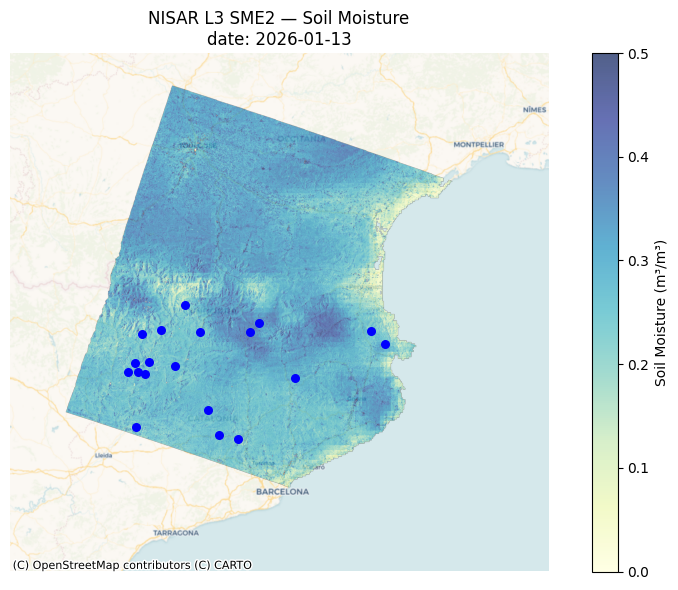

In [9]:
#ploting together with clipped ismn points


with rasterio.open(sm_fp) as src:
    data = src.read(1, masked=True)
    bounds = src.bounds  # left, bottom, right, top

fig, ax = plt.subplots(figsize=(9, 6))

# Draw raster first
img = ax.imshow(
    data,
    cmap="YlGnBu",
    vmin=0, vmax=0.5,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
    origin='upper',
    zorder=2,
    alpha=0.7
)

# Lock axes limits to raster extent BEFORE adding basemap
ax.set_xlim(bounds.left, bounds.right)
ax.set_ylim(bounds.bottom, bounds.top)

# Now add basemap — it will tile to the already-locked extent
contextily.add_basemap(
    ax,
    source=contextily.providers.CartoDB.Voyager,
    crs="EPSG:4326",
    zorder=1
)

precip_clipped.plot(ax=ax, color='blue', markersize=30, zorder=3)

plt.colorbar(img, ax=ax, label="Soil Moisture (m³/m³)")
ax.set_title("NISAR L3 SME2 — Soil Moisture\ndate: 2026-01-13")
ax.axis("off")
plt.tight_layout()
plt.show()

# Precipitation raster

For model run it is needed a precipitation raster. This is achieved with IDW interpolating of points rainfall value.

There was very little rainfall during the selected time so most of the interpolted raster will be zero, but this is still a crucial role in Trafficability model even if it didn't rain.

In [10]:
#interpolating the precipitation now

import numpy as np
import rasterio

def idw_to_match_raster(gdf, column, reference_raster, power=2, outfile=None):
    # read reference raster metadata
    with rasterio.open(reference_raster) as src:
        transform = src.transform
        width = src.width
        height = src.height
        crs = src.crs

    # build grid of pixel centers
    cols = np.arange(width)
    rows = np.arange(height)

    # pixel center coordinates
    grid_x = transform.c + cols * transform.a
    grid_y = transform.f + rows * transform.e

    # expand to 2D meshgrid
    grid_x, grid_y = np.meshgrid(grid_x, grid_y)

    # point coordinates and values
    px = gdf.geometry.x.values.reshape(1, 1, -1)
    py = gdf.geometry.y.values.reshape(1, 1, -1)
    pz = gdf[column].values.reshape(1, 1, -1)

    gx = grid_x[:, :, None]
    gy = grid_y[:, :, None]

    # IDW computation
    dist = np.sqrt((gx - px)**2 + (gy - py)**2)
    dist[dist == 0] = 1e-12  # avoid division by zero

    weights = 1 / dist**power
    num = np.sum(weights * pz, axis=2)
    den = np.sum(weights, axis=2)
    raster = num / den

    # save
    if outfile:
        with rasterio.open(
            outfile,
            "w",
            driver="GTiff",
            height=height,
            width=width,
            count=1,
            dtype=raster.dtype,
            crs=crs,
            transform=transform,
        ) as dst:
            dst.write(raster, 1)

    return raster, transform, crs


In [11]:
raster, transform, crs = idw_to_match_raster(
    precip_clipped,
    column="precip_mm",
    reference_raster=sm_fp,
    outfile="data/gtiff_data/model_data/precip_idw_aligned.tif"
)

print("Interpolated raster crs:", crs)

Interpolated raster crs: EPSG:4326


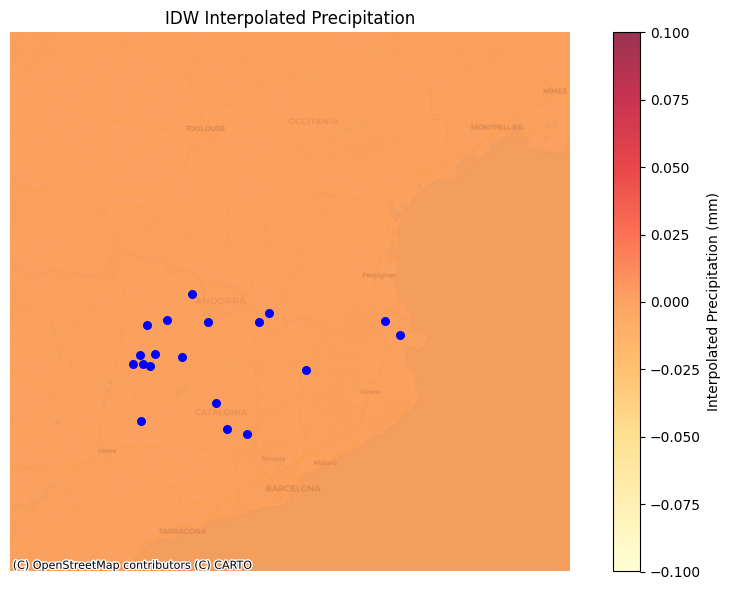

In [12]:
#ploting the interpolated raster now
# compute extent from transform
xmin = transform.c
xmax = xmin + transform.a * raster.shape[1]
ymax = transform.f
ymin = ymax + transform.e * raster.shape[0]

fig, ax = plt.subplots(figsize=(9, 6))

# Draw IDW raster
img = ax.imshow(
    raster,
    cmap="YlOrRd",
    extent=[xmin, xmax, ymin, ymax],
    origin="upper",
    zorder=2,
    alpha=0.8
)

# Lock axes to raster extent
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# Add basemap
contextily.add_basemap(
    ax,
    source=contextily.providers.CartoDB.Voyager,
    crs=crs.to_string(),   # IMPORTANT: use raster CRS
    zorder=1
)

# Plot your precipitation points
precip_clipped.plot(ax=ax, color='blue', markersize=30, zorder=3)

plt.colorbar(img, ax=ax, label="Interpolated Precipitation (mm)")
ax.set_title("IDW Interpolated Precipitation")
ax.axis("off")
plt.tight_layout()
plt.show()


# result is mostly zero mm because AOI had very little rain during that time

# DEM data

Using EU-DEM for this case from https://www.opentopodata.org/datasets/eudem/ 

As the DEM is very large it was cliped in QGIS to right extent before this import to save my computer RAM


In [13]:
# Checking the rasters and DEM crs
print('NISAR SoilMoisture tiff crs:', src.crs)
print('ISMN data crs: ', precip_clipped.crs)

dem_fp = 'data/gtiff_data/dem/dem_clip.tif'

with rasterio.open(dem_fp) as dem_src:
    dem = dem_src.read(1)
    dem_crs = dem_src.crs
    dem_transform = dem_src.transform

print('DEM crs: ', dem_crs)


NISAR SoilMoisture tiff crs: EPSG:4326
ISMN data crs:  EPSG:4326
DEM crs:  EPSG:3035


In [14]:
#want to reproject to 4326, using rioxarray library

dem = rxr.open_rasterio(dem_fp)

dem_4326 = dem.rio.reproject('EPSG:4326')

dem_4326.rio.to_raster('data/gtiff_data/dem/clipped_dem_4326.tif')



# Raster Alignment

All of the rasters ale aligned and resampled to same resolution as is the NISAR soil moisture product.

Created a function for this as it will be needed later aswell

In [15]:
# raster alignment function

def align_raster_to_reference(src_fp, ref_fp, out_fp):
    # Read reference raster metadata
    with rasterio.open(ref_fp) as ref:
        dst_crs = ref.crs
        dst_transform = ref.transform
        dst_width = ref.width
        dst_height = ref.height
        dst_meta = ref.meta.copy()

    # Read source raster
    with rasterio.open(src_fp) as src:
        src_data = src.read(1)

        # Prepare output array
        dst_data = np.empty((dst_height, dst_width), dtype=src_data.dtype)

        # Reproject + resample to reference grid
        reproject(
            source=src_data,
            destination=dst_data,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=dst_transform,
            dst_crs=dst_crs,
            resampling=Resampling.bilinear
        )

    # Save aligned raster
    dst_meta.update({
        "height": dst_height,
        "width": dst_width,
        "transform": dst_transform,
        "crs": dst_crs,
        "dtype": dst_data.dtype
    })


    dst_meta.pop("nodata", None)

    with rasterio.open(out_fp, "w", **dst_meta) as dst:
        dst.write(dst_data, 1)

    print(f"Written {out_fp}")


In [16]:
dem_fp = 'data/gtiff_data/dem/clipped_dem_4326.tif'
dem_out_fp = 'data/gtiff_data/model_data/dem_aligned.tif'

align_raster_to_reference(
    src_fp=dem_fp,
    ref_fp=sm_fp,
    out_fp=dem_out_fp
)

Written data/gtiff_data/model_data/dem_aligned.tif


In [17]:
#checking just in case:

dem_aligned_fp = 'data/gtiff_data/dem/dem_aligned.tif'
with rasterio.open(dem_aligned_fp) as r1, rasterio.open(sm_fp) as r2:
    aligned = (
        r1.crs == r2.crs and
        r1.transform == r2.transform and
        r1.width == r2.width and
        r1.height == r2.height
    )
        # Pixel sizes
    px1 = (r1.transform.a, r1.transform.e)
    px2 = (r2.transform.a, r2.transform.e)

print("Aligned:", aligned)
print("DEM pixel size:", px1)
print("NISAR sm pixel size:", px2)


Aligned: True
DEM pixel size: (0.002088670067417042, -0.002088670067417042)
NISAR sm pixel size: (0.002088670067417042, -0.002088670067417042)


In [18]:
caly_fp = 'data/gtiff_data/clay_05-15.tif'
sand_fp = 'data/gtiff_data/sand_05-15.tif'

with rasterio.open(caly_fp) as r1, rasterio.open(sand_fp) as r2:
    
    # Check alignment
    aligned = (
        r1.crs == r2.crs and
        r1.transform == r2.transform and
        r1.width == r2.width and
        r1.height == r2.height
    )

    # Pixel sizes
    px1 = (r1.transform.a, r1.transform.e)
    px2 = (r2.transform.a, r2.transform.e)
    crs1 = r1.crs
    crs2 = r2.crs

print("Aligned:", aligned)
print("Clay pixel size:", px1)
print("Sand pixel size:", px2)
print("Clay crs:", crs1)
print("Sand crs:", crs2)


Aligned: True
Clay pixel size: (0.0022604764388801948, -0.0023897058823529414)
Sand pixel size: (0.0022604764388801948, -0.0023897058823529414)
Clay crs: EPSG:4326
Sand crs: EPSG:4326


In [19]:
with rasterio.open(caly_fp) as r1, rasterio.open(sm_fp) as r2:
    
    # Check alignment
    aligned = (
        r1.crs == r2.crs and
        r1.transform == r2.transform and
        r1.width == r2.width and
        r1.height == r2.height
    )

    # Pixel sizes
    px1 = (r1.transform.a, r1.transform.e)
    px2 = (r2.transform.a, r2.transform.e)
    crs1 = r1.crs
    crs2 = r2.crs

print("Aligned:", aligned)
print("Clay pixel size:", px1)
print("NISAR sm pixel size:", px2)
print("Clay crs:", crs1)
print("NISAR sm crs:", crs2)

Aligned: False
Clay pixel size: (0.0022604764388801948, -0.0023897058823529414)
NISAR sm pixel size: (0.002088670067417042, -0.002088670067417042)
Clay crs: EPSG:4326
NISAR sm crs: EPSG:4326


In [20]:
clay_out_fp = 'data/gtiff_data/model_data/clay_align.tif'
sand_out_fp = 'data/gtiff_data/model_data/sand_align.tif'

align_raster_to_reference(
    src_fp=caly_fp,
    ref_fp=sm_fp,
    out_fp=clay_out_fp
)

align_raster_to_reference(
    src_fp=sand_fp,
    ref_fp=sm_fp,
    out_fp=sand_out_fp
)

with rasterio.open(clay_out_fp) as r1, rasterio.open(sm_fp) as r2:
    
    # Check alignment
    aligned = (
        r1.crs == r2.crs and
        r1.transform == r2.transform and
        r1.width == r2.width and
        r1.height == r2.height
    )

    # Pixel sizes
    px1 = (r1.transform.a, r1.transform.e)
    px2 = (r2.transform.a, r2.transform.e)
    crs1 = r1.crs
    crs2 = r2.crs

print("Aligned:", aligned)
print("Clay pixel size:", px1)
print("NISAR sm pixel size:", px2)
print("Clay crs:", crs1)
print("NISAR sm crs:", crs2)



Written data/gtiff_data/model_data/clay_align.tif
Written data/gtiff_data/model_data/sand_align.tif
Aligned: True
Clay pixel size: (0.002088670067417042, -0.002088670067417042)
NISAR sm pixel size: (0.002088670067417042, -0.002088670067417042)
Clay crs: EPSG:4326
NISAR sm crs: EPSG:4326


In [21]:
#importing and merging THS rasters

def raster_merge(folder_fp, tif_name):
    folder = Path(folder_fp)

    #listing all the rasters
    rasters = [rasterio.open(fp) for fp in folder.glob('*.tif')]

    #mergig all the tiles
    mosaic, out_transform = merge(rasters)

    # coping metadata
    meta = rasters[0].meta.copy()

    meta.update({
        'height': mosaic.shape[1],
        'width': mosaic.shape[2],
        'transform':out_transform
    })

    with rasterio.open(f"data/gtiff_data/{tif_name}.tif", 'w', **meta) as dst:
        dst.write(mosaic)

    for rast in rasters:
        rast.close()
    
    print(f"Merging {tif_name} done!")

In [22]:
raster_merge(
    folder_fp='data/gtiff_data/ths_30',
    tif_name='ths_30')

raster_merge(
    folder_fp='data/gtiff_data/ths_15',
    tif_name='ths_15')

Merging ths_30 done!
Merging ths_15 done!


# Corine data
2018 raster was used

As DEM was clipped in QGIS, wanted to try this aswell in python, to roughly clip the raster to AOI

In [23]:
# cliping the corine raster with defined bounds since this is too much for my computer ram to clip with other rasters

src_fp = 'data/gtiff_data/corine.tif'
out_fp = 'data/gtiff_data/corine_clip.tif'

# bounding box in EPSG:3035
left   = 3200000
bottom = 1750000
right  = 3800000
top    = 2500000



with rasterio.open(src_fp) as src:
    window = from_bounds(left, bottom, right, top, src.transform)
    clipped = src.read(window=window)
    out_transform = src.window_transform(window)

    meta = src.meta.copy()
    meta.update({
        "height": clipped.shape[1],
        "width": clipped.shape[2],
        "transform": out_transform
    })

with rasterio.open(out_fp, "w", **meta) as dst:
    dst.write(clipped)

In [24]:
#reporojecting function for easyer use
def reproject_raster(raster_fp, crs_out, fp_out):
    dem = rxr.open_rasterio(raster_fp)

    dem_4326 = dem.rio.reproject(crs_out)

    dem_4326.rio.to_raster(fp_out)

    print(f"{raster_fp} projected to {crs_out}")

In [25]:
#reprojecting all the rasters

reproject_raster(
    raster_fp='data/gtiff_data/corine_clip.tif',
    crs_out='EPSG:4326',
    fp_out='data/gtiff_data/reproj/corine.tif'
)

reproject_raster(
    raster_fp='data/gtiff_data/ths_15.tif',
    crs_out='EPSG:4326',
    fp_out='data/gtiff_data/reproj/ths_15.tif'
)

reproject_raster(
    raster_fp='data/gtiff_data/ths_30.tif',
    crs_out='EPSG:4326',
    fp_out='data/gtiff_data/reproj/ths_30.tif'
)

data/gtiff_data/corine_clip.tif projected to EPSG:4326
data/gtiff_data/ths_15.tif projected to EPSG:4326
data/gtiff_data/ths_30.tif projected to EPSG:4326


In [26]:
#Now aligning all the rasters to NISAR soilmoisture
align_raster_to_reference(
    src_fp='data/gtiff_data/reproj/ths_30.tif',
    ref_fp=sm_fp,
    out_fp='data/gtiff_data/model_data/ths_30.tif'
)

align_raster_to_reference(
    src_fp='data/gtiff_data/reproj/ths_15.tif',
    ref_fp=sm_fp,
    out_fp='data/gtiff_data/model_data/ths_15.tif'
)

align_raster_to_reference(
    src_fp='data/gtiff_data/reproj/corine.tif',
    ref_fp=sm_fp,
    out_fp='data/gtiff_data/model_data/corine.tif'
)

Written data/gtiff_data/model_data/ths_30.tif
Written data/gtiff_data/model_data/ths_15.tif
Written data/gtiff_data/model_data/corine.tif


In [27]:
with rasterio.open('data/gtiff_data/model_data/ths_30.tif') as r1, rasterio.open(sm_fp) as r2:
    
    # Checking alignment
    aligned = (
        r1.crs == r2.crs and
        r1.transform == r2.transform and
        r1.width == r2.width and
        r1.height == r2.height
    )

    # Pixel sizes
    px1 = (r1.transform.a, r1.transform.e)
    px2 = (r2.transform.a, r2.transform.e)
    crs1 = r1.crs
    crs2 = r2.crs

print("Aligned:", aligned)
print("THS pixel size:", px1)
print("NISAR sm pixel size:", px2)
print("THS crs:", crs1)
print("NISAR sm crs:", crs2)

Aligned: True
THS pixel size: (0.002088670067417042, -0.002088670067417042)
NISAR sm pixel size: (0.002088670067417042, -0.002088670067417042)
THS crs: EPSG:4326
NISAR sm crs: EPSG:4326


# Simple RCI Trafficability Model
 
## Overview
 
This model produces a pixel-level **Rating Cone Index (RCI)** raster for terrain
trafficability assessment, and later compares the result against vehicle-specific
**Vehicle Cone Index (VCI)** thresholds derived from the NATO Reference Mobility
Model (NRMM II) to classify terrain as GO, SLOW-GO, or NO-GO.
 
The model is intentionally simple. It does not use machine learning or
high-resolution optical remote sensing. Instead it relies on freely available
global raster datasets and established empirical soil strength equations.
 
---
 
## RCI Model
 
RCI is computed using a linear interpolation between dry and saturated soil
strength, modulated by effective saturation, slope, and rainfall:
 
```
Se  = clip(sm / theta_s, 0, 1)
RCI = RCI_dry * (1 - Se) + RCI_sat * Se
RCI = RCI - slope_penalty * slope_deg
RCI = RCI - rainfall_softening * clip(rainfall, 0, 100)
RCI = clip(RCI, 0, 700)  [kPa]
```
 
### Inputs
 
| Input | Source | Description |
|-------|--------|-------------|
| Soil moisture (θ) | NISAR SAR | Volumetric soil moisture [m³/m³] |
| Saturated water content (θs) | EU-SoilHydroGrids 15+30 cm | Fallback: texture-class lookup |
| Sand / Clay content | SoilGrids 15–30 cm | Used for texture classification and θs fallback |
| DEM | Copernicus 30 m | Used to derive slope |
| Precipitation | IDW-interpolated rainfall | Recent rainfall softening term |
| Land cover | CORINE | Mask -> open terrain classes only |
 
### Soil Texture Classification
 
Each pixel is classified into one of three texture classes based on sand and
clay percentage from SoilGrids:
 
| Class | Condition |
|-------|-----------|
| Sandy | sand > 70% |
| Clayey | clay > 35% |
| Loamy | everything else |
 
### RCI Parameters by Texture
 
| Texture | RCI dry (kPa) | RCI saturated (kPa) |
|---------|--------------|-------------------|
| Sandy | 600 | 200 |
| Loamy | 500 | 100 |
| Clayey | 400 | 40 |
 
### Slope and Rainfall Penalties
 
- Slope penalty: **8.0 kPa per degree**
- Rainfall softening: **1.2 kPa per mm** (capped at 100 mm)
---
 


## Comparison with Wang et al. (2024)
 
Wang et al. (2024) *"A novel finer soil strength mapping framework based on
machine learning and remote sensing images"*, Computers & Geosciences 182,
105479 — presents a more complex framework for the same goal of pixel-level
RCI mapping. The key differences are:
 
### RCI Formula
 
Both models use the same underlying SMSP (Soil Moisture Strength Prediction)
empirical equation from WES. Wang et al. use the original exponential form:
 
```
RCI = exp(a + b * ln(Mg))
```
 
where `Mg` is **gravimetric** soil moisture and `a`, `b` are USCS soil-class
coefficients (Table 3 in Wang et al.).
 
This model uses a **linear interpolation** between dry and saturated RCI
anchored by effective saturation `Se = θ / θs`. This is a simplification as
it avoids the need for USCS classification and gravimetric moisture conversion,
at the cost of less soil-class specificity.
 
### Soil Classification
 
Wang et al. predict full **USCS soil classification** (10 classes: SP, SM, SC,
ML, CL, CL-ML, MH, CH, SP-SM, SC-SM) using XGBoost trained on 93,499 samples
from the gSSURGO database, then transferred to SoilGrids. This is the most
complex part of their pipeline.
 
This model uses a simplified **3-class texture scheme** (sandy, loamy, clayey)
derived directly from SoilGrids sand and clay percentages. No machine learning
is used for soil classification.
 
### Soil Moisture
 
Wang et al. retrieve soil moisture at **critical depth (20 cm)** using GBDT
trained on Sentinel-2 spectral indices, topographic data, and soil properties
achieving R² of 0.533–0.694 at 20 cm depth.
 
This model uses **NISAR SAR-derived surface soil moisture** directly as input.
Wang et al. note that surface soil moisture products are only reliable above
5 cm, and that critical RCI should be measured at the sub-surface layer depth
around 6 inches. This is a known limitation of this model as the soil
moisture input represents surface conditions, not necessarily the critical layer.
 
### Saturated Water Content (θs)
 
This model uses **EU-SoilHydroGrids** at 15 cm and 30 cm depth to build the θs
layer, with fallback to texture-class values (0.43 sandy, 0.46 loamy, 0.51
clayey) where raster data is missing or out of valid range.
 
Wang et al. do not use θs directly — their SMSP formulation works with
gravimetric moisture and USCS coefficients, so θs is not needed.
 
### Land Cover Masking
 
This model applies a **CORINE land cover mask** to restrict output to open
terrain (agricultural land, natural grassland, sparse vegetation, wetlands).
Urban areas, forests, and water bodies are excluded as they are not relevant
for off-road vehicle trafficability.
 
Wang et al. do not apply a land cover mask — their study site in the Shandian
River Basin is predominantly cropland and grassland by default.
 
### Additional Terrain Factors
 
This model includes **slope** (derived from a 30 m DEM) and **recent rainfall**
as softening penalties on RCI. These are not present in the Wang et al. SMSP
formulation, which uses soil moisture as the sole dynamic driver.
 



In [28]:
#Creating now the RCI classification model


INPUT_DIR = Path("data/gtiff_data/model_data")
OUTPUT_DIR = Path("data/gtiff_data/outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

FILES = {
    "sm": INPUT_DIR / "soilMoisture_4326.tif",
    "sand": INPUT_DIR / "sand_align.tif",
    "clay": INPUT_DIR / "clay_align.tif",
    "ths_15": INPUT_DIR / "ths_15.tif",
    "ths_30": INPUT_DIR / "ths_30.tif",
    "dem": INPUT_DIR / "dem_aligned.tif",
    "rainfall": INPUT_DIR / "precip_idw_aligned.tif",
    "corine": INPUT_DIR / "corine.tif",
}

OUTPUT_FILE = OUTPUT_DIR / "rci_simple.tif"

# CORINE class sets 

CORINE_OPEN_CLASSES = {
    211, 212, 213,
    221, 222, 223,
    231,
    241, 242, 243, 244,
    321, 322, 323, 324,
    331, 332, 333, 334,
    411, 412,
}

CORINE_OPEN_CLASSES_STRICT = {
    211, 212, 213,
    231,
    241, 242, 243,
    321,
}

ACTIVE_CORINE_MASK = CORINE_OPEN_CLASSES

# Fallback θs by texture 

THETA_S_FALLBACK = {
    "sandy":  0.43,
    "loamy":  0.46,
    "clayey": 0.51,
}

# RCI parameters 

RCI_PARAMS = {
    "sandy":  (600, 200),
    "loamy":  (500, 100),
    "clayey": (400,  40),
}

SLOPE_PENALTY_PER_DEG    = 8.0
RAINFALL_SOFTENING_PER_MM = 1.2


# I/O helpers

def load_reference(path: Path):
    with rasterio.open(path) as src:
        data   = src.read(1).astype(np.float32)
        meta   = src.meta.copy()
        nodata = src.nodata
    if nodata is not None:
        data = np.where(data == nodata, np.nan, data)
    return data, meta


def load_aligned(path: Path, ref_meta: dict,
                 resampling=Resampling.bilinear) -> np.ndarray:
    with rasterio.open(path) as src:
        dst = np.empty((ref_meta["height"], ref_meta["width"]), dtype=np.float32)
        nodata = src.nodata

        reproject(
            source=rasterio.band(src, 1), destination=dst,
            src_transform=src.transform, src_crs=src.crs,
            dst_transform=ref_meta["transform"], dst_crs=ref_meta["crs"],
            resampling=resampling,
        )

        # Treating 255 as nodata if nodata is missing or equals 255
        if nodata is None or nodata == 255:
            dst = np.where(dst == 255, np.nan, dst)
        else:
            dst = np.where(dst == nodata, np.nan, dst)

    return dst



def try_load_aligned(path: Path, ref_meta: dict,
                     resampling=Resampling.bilinear):
    if not path.exists():
        print(f"  [warn] {path.name} not found — will use fallback")
        return None
    return load_aligned(path, ref_meta, resampling)


# Model helpers

def classify_texture(sand_pct: np.ndarray, clay_pct: np.ndarray) -> np.ndarray:
    tex = np.ones_like(sand_pct, dtype=np.int8)
    tex = np.where(sand_pct > 70, 0, tex)
    tex = np.where(clay_pct > 35, 2, tex)
    return tex


def build_theta_s(ths_15, ths_30, tex: np.ndarray) -> np.ndarray:
    fallback = np.select(
        [tex == 0, tex == 1, tex == 2],
        [THETA_S_FALLBACK["sandy"],
         THETA_S_FALLBACK["loamy"],
         THETA_S_FALLBACK["clayey"]],
    ).astype(np.float32)

    if ths_15 is None and ths_30 is None:
        print("  θs: texture-class fallback (no THS rasters found)")
        return fallback

    def _rescale(arr):
        if arr is None:
            return None
        arr = arr.astype(np.float32)
        valid = arr[~np.isnan(arr)]
        if valid.size > 0 and np.nanmedian(valid) > 1.5 and np.nanmedian(valid) < 100:
            print("  THS appears to be integer percent — dividing by 100")
            arr = arr / 100.0
        return arr


    ths_15 = _rescale(ths_15)
    ths_30 = _rescale(ths_30)

    if ths_15 is not None and ths_30 is not None:
        raster = np.nanmean(np.stack([ths_15, ths_30], axis=0), axis=0)
    elif ths_15 is not None:
        raster = ths_15
    else:
        raster = ths_30

    raster = np.where((raster > 0.20) & (raster <= 0.75), raster, np.nan)

    theta_s = np.where(np.isnan(raster), fallback, raster)
    print(f"  θs: raster={(~np.isnan(raster)).sum():,} px  |  "
          f"fallback={np.isnan(raster).sum():,} px  "
          f"|  range {np.nanmin(raster):.3f}–{np.nanmax(raster):.3f}")
    return theta_s.astype(np.float32)


def build_corine_mask(corine, open_classes: set) -> np.ndarray:
    if corine is None:
        print("  CORINE absent — processing all pixels")
        return None

    # Full CORINE Level-2 → Level-3 mapping (1–48). this is needed because raster uses 1-48 classification
    CORINE_L2_TO_L3 = {
        # Artificial surfaces (closed)
        1: 111, 2: 112, 3: 121, 4: 122, 5: 123, 6: 124,
        7: 131, 8: 132, 9: 133, 10: 141, 11: 142,

        # Agricultural (open)
        12: 211, 13: 212, 14: 213,
        15: 221, 16: 222, 17: 223,
        18: 231,
        19: 241, 20: 242, 21: 243, 22: 244,

        # Forest & semi-natural
        23: 311, 24: 312, 25: 313,
        26: 321, 27: 322, 28: 323, 29: 324,
        30: 331, 31: 332, 32: 333, 33: 334,

        # Wetlands
        34: 411, 35: 412, 36: 421, 37: 422,

        # Water bodies (closed)
        38: 511, 39: 512, 40: 521, 41: 522, 42: 523,
    }

    # Default for unknown classes → closed terrain
    DEFAULT_CLOSED = 999

    # Vectorized mapping with fallback
    mapper = np.vectorize(lambda x: CORINE_L2_TO_L3.get(int(x), DEFAULT_CLOSED))
    corine_mapped = mapper(corine)

    # Mask only open classes
    mask = np.isin(corine_mapped, list(open_classes))

    n_total = int((~np.isnan(corine.astype(float))).sum())
    n_open  = int(mask.sum())
    print(f"  CORINE: {n_open:,} open px / {n_total:,} total "
          f"({n_open / max(n_total, 1) * 100:.1f}% retained)")

    return mask



def compute_slope_deg(dem: np.ndarray, transform) -> np.ndarray:
    res = abs(transform.a)
    if res < 0.01:
        res *= 111_320
    dz_dx = np.gradient(np.nan_to_num(dem, nan=0.0), res, axis=1)
    dz_dy = np.gradient(np.nan_to_num(dem, nan=0.0), res, axis=0)
    slope = np.degrees(np.arctan(np.sqrt(dz_dx**2 + dz_dy**2)))
    return uniform_filter(slope, size=3)


# Core RCI model 

def compute_rci(sm, sand, clay, theta_s, dem, rainfall,
                transform, open_mask) -> np.ndarray:

    sand_pct = sand / 10.0
    clay_pct = clay / 10.0
    tex = classify_texture(sand_pct, clay_pct)

    Se = np.clip(sm / theta_s, 0.0, 1.0)

    rci_dry = np.select(
        [tex == 0, tex == 1, tex == 2],
        [RCI_PARAMS["sandy"][0], RCI_PARAMS["loamy"][0], RCI_PARAMS["clayey"][0]],
    ).astype(np.float32)

    rci_sat = np.select(
        [tex == 0, tex == 1, tex == 2],
        [RCI_PARAMS["sandy"][1], RCI_PARAMS["loamy"][1], RCI_PARAMS["clayey"][1]],
    ).astype(np.float32)

    rci = rci_dry * (1.0 - Se) + rci_sat * Se

    rci -= SLOPE_PENALTY_PER_DEG * compute_slope_deg(dem, transform)
    rci -= RAINFALL_SOFTENING_PER_MM * np.clip(rainfall, 0.0, 100.0)
    rci  = np.clip(rci, 0.0, 700.0)

    nan_mask = (
        np.isnan(sm) | np.isnan(sand) | np.isnan(clay) |
        np.isnan(theta_s) | np.isnan(dem) | np.isnan(rainfall)
    )
    rci[nan_mask] = np.nan

    if open_mask is not None:
        rci[~open_mask] = np.nan

    return rci


# Main function to call all other model functions

def main():
    print("Loading reference grid (NISAR soil moisture)…")
    sm, ref_meta = load_reference(FILES["sm"])

    print("Loading ancillary inputs…")
    sand = load_aligned(FILES["sand"],     ref_meta)
    clay = load_aligned(FILES["clay"],     ref_meta)
    dem = load_aligned(FILES["dem"],      ref_meta)
    rainfall = load_aligned(FILES["rainfall"], ref_meta)
    ths_15 = try_load_aligned(FILES["ths_15"], ref_meta)
    ths_30 = try_load_aligned(FILES["ths_30"], ref_meta)
    corine = try_load_aligned(FILES["corine"], ref_meta,
                                resampling=Resampling.nearest)

    print("Building θs layer…")
    tex = classify_texture(sand / 10.0, clay / 10.0)
    theta_s = build_theta_s(ths_15, ths_30, tex)

    print("Building land-cover mask…")
    open_mask = build_corine_mask(corine, ACTIVE_CORINE_MASK)

    print("Running RCI model…")
    rci = compute_rci(sm, sand, clay, theta_s, dem, rainfall,
                      ref_meta["transform"], open_mask)

    valid = rci[~np.isnan(rci)]
    if valid.size == 0:
        print("  !!! No valid output pixels — check inputs and CORINE mask. !!!")
        return

    lo  = (valid < 100).sum() / valid.size * 100
    mid = ((valid >= 100) & (valid < 300)).sum() / valid.size * 100
    hi  = (valid >= 300).sum() / valid.size * 100

    print(f"RCI range: {valid.min():.1f} – {valid.max():.1f} kPa")
    print(f"RCI mean: {valid.mean():.1f} kPa")
    print(f"RCI median: {np.median(valid):.1f} kPa")
    print(f"High risk (<100 kPa): {lo:.1f}%")
    print(f"Moderate (100–300): {mid:.1f}%")
    print(f"Trafficable (>300 kPa): {hi:.1f}%")

    out_meta = ref_meta.copy()
    out_meta.update({"dtype": "float32", "count": 1, "nodata": np.nan,
                     "compress": "deflate", "predictor": 3})

    print(f"Writing -> {OUTPUT_FILE}")
    with rasterio.open(OUTPUT_FILE, "w", **out_meta) as dst:
        dst.write(rci.astype(np.float32), 1)
        dst.update_tags(
            model="RCI Simple v2", rci_units="kPa",
            sm_source="NISAR", soil_source="SoilGrids 15-30cm",
            ths_source="EU-SoilHydroGrids 15+30cm (fallback: texture)",
            lc_mask="CORINE open terrain", rci_low="100", rci_high="300",
        )
    print("Done.")


In [29]:
main()

Loading reference grid (NISAR soil moisture)…
Loading ancillary inputs…
Building θs layer…
  THS appears to be integer percent — dividing by 100
  THS appears to be integer percent — dividing by 100


/tmp/ipykernel_10758/3255451165.py:141: RuntimeWarning: Mean of empty slice
  raster = np.nanmean(np.stack([ths_15, ths_30], axis=0), axis=0)


  θs: raster=2,520,223 px  |  fallback=1,046,837 px  |  range 0.395–0.750
Building land-cover mask…
  CORINE: 1,594,611 open px / 3,567,060 total (44.7% retained)
Running RCI model…
RCI range: 0.0 – 488.5 kPa
RCI mean: 205.2 kPa
RCI median: 205.5 kPa
High risk (<100 kPa): 6.1%
Moderate (100–300): 87.6%
Trafficable (>300 kPa): 6.4%
Writing -> data/gtiff_data/outputs/rci_simple.tif
Done.


In [30]:
# differences between 

# Clarification of vehicle cone index with reference
# to mean maximum pressure
# Jody D. Priddy *, William E. Willoughby
# https://www.researchgate.net/publication/223764853_Clarification_of_vehicle_cone_index_with_reference_to_mean_maximum_pressure

# and 

# Semi-Empiric Algorithm for Assessment of the Vehicle Mobility
# Ticusor CIOBOTARU
# https://www.researchgate.net/publication/40822199_Semi-Empiric_Algorithm_for_Assessment_of_the_Vehicle_Mobility




#need imperial units conversion
def kg_to_lb(kg):
    return kg*2.20462

def mm_to_in(mm):
    return mm / 25.4

def psi_to_kpa(psi):
    return psi / 0.14504

def kpa_to_psi(kpa):
    return kpa * 0.14504


## calculating VCI for HMMWV

vehicle = "HMMWV"

vehicle_type = 'wheeled'
gross_weight_kg = 5897
tire_width_mm = 317.5
tire_diameter_mm = 939.8
rim_diameter_mm   = 419.1 
num_tires = 4
axles_count = 2
ground_clearence_mm = 400
engine_power_hp = 205
transmission_type = 'automatic'
chains_used = False



# w = weight beneath the assembly (i.e per axle)
# n = number of tires on that assembly (i.e per axle)
# d = tire outside diameter [in]
# b = tire section width [in]
# delta = tire hard-surface deflection under load at scenario inflation pressure [in]
    # typical range: 0.8–2.0 in for military/off-road tires
# hc = minimum ground clearance of the assembly [in]
# measured as the lowest point of the vehicle belly above flat ground
# g = grouser height [in]  (tracked vehicles only)
# PWR = engine gross power-to-weight ratio [hp / short ton], = 1 if PWR < 10 hp=ton or 0 if not;
# delta = hard-surface tire deflection [in]
    # ASSUMED as 15% of section height

#converting to imperial units
w = kg_to_lb(gross_weight_kg) / axles_count
n = num_tires / axles_count
d = mm_to_in(tire_diameter_mm)
b = mm_to_in(tire_width_mm)
hc = mm_to_in(ground_clearence_mm)
h = (mm_to_in(tire_diameter_mm) - mm_to_in(rim_diameter_mm)) / 2 
delta = h * 0.15 

# contact pressure factor
def calc_cpf(w, n, d, b):
    cpf = w / (0.5 * n * d * b)
    return cpf

# traction element factor
def calc_tef(b):  
    tef = (10+b) / 100
    return tef

# wheel load factor
def calc_wlf(w):
    wlf = w / 2000
    return wlf

#clearence factor
def calc_cf(hc):  
    cf = hc / 10
    return cf

#Grouser factor
def calc_gf(chains): 
    if chains:
        gf = 1 + 0.05 * 1
    else:
        gf = 1 + 0.05 * 0
    return gf

# engine factor
# !note: This uses metric tonnes
def calc_ef(hp, weight_kg):
    pwr = hp / (weight_kg / 1000)  
    if pwr < 10:
        ef = 1 + 0.05 * 1       
    else:
        ef = 1 + 0.05 * 0          
    return ef

# weight factor
def calc_wf(w):
    # w = weight per axle [lbf]
    w_klbf = w / 1000
    if w < 2000:
        wf = 0.553 * w_klbf + 0.000
    elif w < 13500:
        wf = 0.033 * w_klbf + 1.050
    elif w < 20000:
        wf = 0.142 * w_klbf + (-0.420)
    elif w < 31500:
        wf = 0.278 * w_klbf + (-3.115)
    else:
        wf = 0.836 * w_klbf + (-20.686)
    return wf

# transmission factor
def calc_tf(transmission_type):
    if transmission_type == 'manual':
        tf = 1 + 0.05 * 1
    else:
        tf = 1 + 0.05 * 0
    return tf





def mobility_index(cpf, wf, tef, gf, wlf, cf, ef, tf):
    MI = ((cpf * wf) / (tef * gf) + wlf - cf) * ef * tf
    return MI

# wheel data?
# https://aaa1surplus.com/guides.html
def calc_dcf(delta, h):
    # Priddy & Willoughby (2006), eq. DCF
    # delta = hard-surface tire deflection [in]
    # h     = tire section height [in]
    dcf = (0.15 / (delta / h)) ** 0.25
    return dcf


# went with J.D. Priddy formula as he is more prominent in this field and it seems that 
# Ciobotaru has made typos in formulas or misread them
def calc_vci1(MI, dcf):
    # Priddy & Willoughby (2006) — exact formula from paper
    if MI <= 115:
        vci1 = (11.48 + 0.2 * MI - 39.2 / (MI + 3.74)) * dcf
    else:
        vci1 = 4.1 * MI ** 0.446 * dcf
    return vci1

def calc_vci50(MI, dcf):
    # Ciobotaru (2009) — VCI50 with same DCF correction applied by analogy
    # WARNING: VCI50 formula is from Ciobotaru, not verified against NRMM II source
    if MI <= 115:
        vci50 = (28.23 + 0.43 * MI - 92.67 / (MI + 3.74)) * dcf
    else:
        vci50 = 9.0 * MI ** 0.446 * dcf
    return vci50


cpf = calc_cpf(w, n, d, b)
tef = calc_tef(b)
wlf = calc_wlf(w)
cf  = calc_cf(hc)
gf  = calc_gf(chains_used)
ef  = calc_ef(engine_power_hp, gross_weight_kg)
wf  = calc_wf(w)
tf  = calc_tf(transmission_type)
dcf = calc_dcf(delta, h)

MI  = mobility_index(cpf, wf, tef, gf, wlf, cf, ef, tf)
vci1 = calc_vci1(MI, dcf)
vci50 = calc_vci50(MI, dcf)

#they are calculated in psi, need to convert to kPa to compare with RCI values
print(f"Mobility index for {vehicle}: {psi_to_kpa(MI):.2f} kPa")
print(f"VCI 1 for {vehicle}: {psi_to_kpa(vci1):.2f} kPa")
print(f"VCI 50 for {vehicle}: {psi_to_kpa(vci50):.2f} kPa")

Mobility index for HMMWV: 556.15 kPa
VCI 1 for HMMWV: 187.18 kPa
VCI 50 for HMMWV: 426.21 kPa


In [31]:


# converting the VCI from psi to kPa
vci1_kpa  = psi_to_kpa(vci1)
vci50_kpa = psi_to_kpa(vci50)


with rasterio.open("data/gtiff_data/outputs/rci_simple.tif") as src:
    rci  = src.read(1).astype(np.float32)
    meta = src.meta.copy()

meta.update({
    "dtype":    "float32",
    "nodata":   np.nan,
    "compress": "deflate",
})


#setting the margin for slow go thershold, can be different
slow_go_margin_kpa = 20.0

def classify(rci, threshold_kpa, margin_kpa):
    # 0 = NO-GO (RCI < threshold - margin)
    # 1 = SLOW-GO (threshold - margin <= RCI < threshold + margin)
    # 2 = GO (RCI >= threshold + margin)
    result = np.full_like(rci, fill_value=np.nan, dtype=np.float32)
    result = np.where(rci >= threshold_kpa + margin_kpa, 2.0, result)  # GO
    result = np.where((rci >= threshold_kpa - margin_kpa) & 
                      (rci <  threshold_kpa + margin_kpa), 1.0, result) # SLOW-GO
    result = np.where(rci <  threshold_kpa - margin_kpa, 0.0, result)  # NO-GO
    result = np.where(np.isnan(rci), np.nan, result)                   # nodata
    return result.astype(np.float32)

# Exporting vci 1 raster
with rasterio.open("data/gtiff_data/outputs/mobility_vci1.tif", "w", **meta) as dst:
    dst.write(classify(rci, vci1_kpa, slow_go_margin_kpa), 1)
    dst.update_tags(
        vehicle = vehicle,
        vci1_kpa = f"{vci1_kpa:.1f}",
        slow_go_margin = f"{slow_go_margin_kpa} kPa",
        class_0 = f"NO-GO (RCI < {vci1_kpa - slow_go_margin_kpa:.1f} kPa)",
        class_1 = f"SLOW-GO ({vci1_kpa - slow_go_margin_kpa:.1f} <= RCI < {vci1_kpa + slow_go_margin_kpa:.1f} kPa)",
        class_2 = f"GO (RCI >= {vci1_kpa + slow_go_margin_kpa:.1f} kPa)",
    )

# Exporting vci 50 raster
with rasterio.open("data/gtiff_data/outputs/mobility_vci50.tif", "w", **meta) as dst:
    dst.write(classify(rci, vci50_kpa, slow_go_margin_kpa), 1)
    dst.update_tags(
        vehicle = vehicle,
        vci50_kpa = f"{vci50_kpa:.1f}",
        slow_go_margin = f"{slow_go_margin_kpa} kPa",
        class_0 = f"NO-GO (RCI < {vci50_kpa - slow_go_margin_kpa:.1f} kPa)",
        class_1 = f"SLOW-GO ({vci50_kpa - slow_go_margin_kpa:.1f} <= RCI < {vci50_kpa + slow_go_margin_kpa:.1f} kPa)",
        class_2 = f"GO (RCI >= {vci50_kpa + slow_go_margin_kpa:.1f} kPa)",
    )

# printing the stats now
valid = rci[~np.isnan(rci)]
for label, threshold in [("VCI1  (1 pass) ", vci1_kpa), ("VCI50 (50 pass)", vci50_kpa)]:
    go = (valid >= threshold + slow_go_margin_kpa).sum() / valid.size * 100
    slowgo = ((valid >= threshold - slow_go_margin_kpa) & 
              (valid <  threshold + slow_go_margin_kpa)).sum() / valid.size * 100
    nogo = (valid <  threshold - slow_go_margin_kpa).sum() / valid.size * 100
    print(f"{label} {threshold:.1f} kPa | GO={go:.1f}% SLOW-GO={slowgo:.1f}% NO-GO={nogo:.1f}%")

VCI1  (1 pass)  187.2 kPa | GO=48.8% SLOW-GO=26.3% NO-GO=24.9%
VCI50 (50 pass) 426.2 kPa | GO=0.3% SLOW-GO=0.5% NO-GO=99.1%


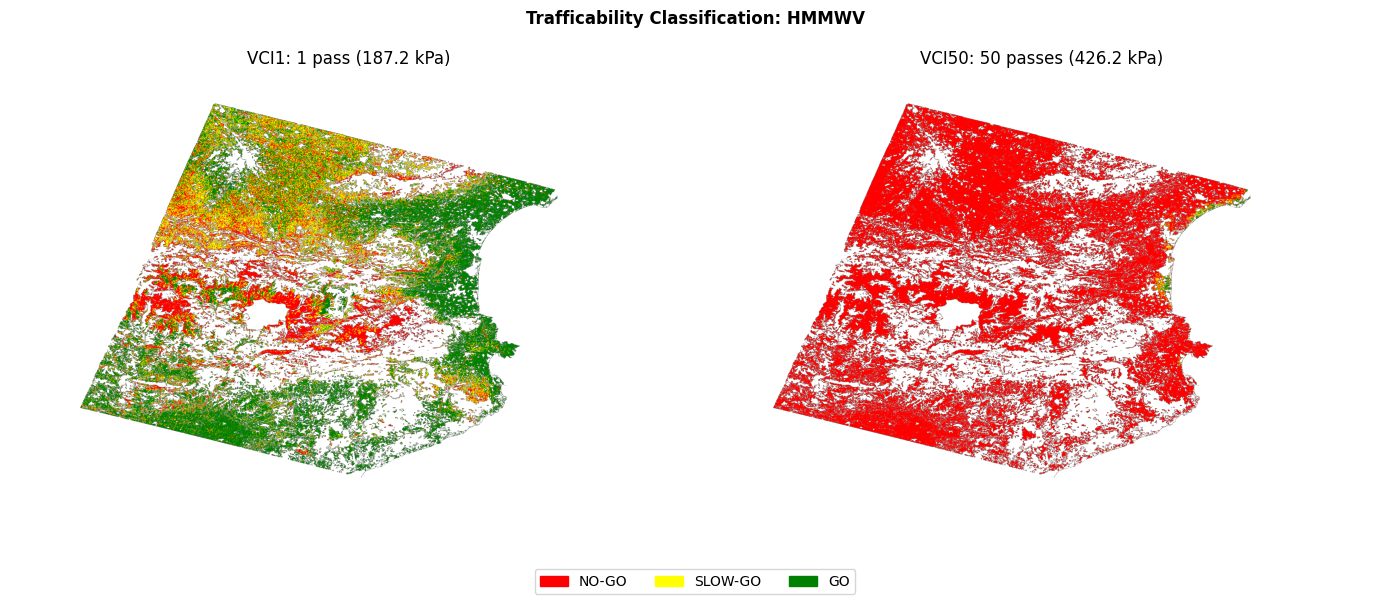

In [32]:
#plotting the two rasters now side by side

with rasterio.open("data/gtiff_data/outputs/mobility_vci1.tif") as src:
    vci1_raster = src.read(1).astype(np.float32)

with rasterio.open("data/gtiff_data/outputs/mobility_vci50.tif") as src:
    vci50_raster = src.read(1).astype(np.float32)

cmap = ListedColormap(["red", "yellow", "green"])

legend = [
    Patch(color="red", label="NO-GO"),
    Patch(color="yellow", label="SLOW-GO"),
    Patch(color="green", label="GO"),
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.imshow(np.ma.masked_invalid(vci1_raster), cmap=cmap, vmin=0, vmax=2)
ax1.set_title(f"VCI1: 1 pass ({vci1_kpa:.1f} kPa)")
ax1.axis("off")

ax2.imshow(np.ma.masked_invalid(vci50_raster), cmap=cmap, vmin=0, vmax=2)
ax2.set_title(f"VCI50: 50 passes ({vci50_kpa:.1f} kPa)")
ax2.axis("off")

fig.legend(handles=legend, loc="lower center", ncol=3)
plt.suptitle(f"Trafficability Classification: {vehicle}", fontweight="bold")
plt.tight_layout()
plt.savefig("data/gtiff_data/outputs/mobility_map.png", dpi=150, bbox_inches="tight")
plt.show()